# **Project Name**    -



##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual/Team
##### **Team Member 1 -**
##### **Team Member 2 -**
##### **Team Member 3 -**
##### **Team Member 4 -**

# **Project Summary -**

Write the summary here within 500-600 words.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


**Write Problem Statement Here.**

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style("whitegrid")


### Dataset Loading

In [2]:
# Load Dataset
DATA_PATH = "pulse/data"

# aggregated transaction
agg_trans_list = []
agg_trans_path = os.path.join(DATA_PATH, "aggregated", "transaction", "country", "india", "state")

for state in os.listdir(agg_trans_path):
    state_path = os.path.join(agg_trans_path, state)
    for year in os.listdir(state_path):
        year_path = os.path.join(state_path, year)
        for file in os.listdir(year_path):
            filepath = os.path.join(year_path, file)
            with open(filepath) as f:
                data = json.load(f)
            for item in data["data"]["transactionData"]:
                agg_trans_list.append({
                    "State": state,
                    "Year": int(year),
                    "Quarter": int(file.strip(".json")),
                    "Transaction_Type": item["name"],
                    "Transaction_Count": item["paymentInstruments"][0]["count"],
                    "Transaction_Amount": item["paymentInstruments"][0]["amount"]
                })

df_agg_trans = pd.DataFrame(agg_trans_list)

# aggregated user
agg_user_list = []
agg_user_path = os.path.join(DATA_PATH, "aggregated", "user", "country", "india", "state")

for state in os.listdir(agg_user_path):
    state_path = os.path.join(agg_user_path, state)
    for year in os.listdir(state_path):
        year_path = os.path.join(state_path, year)
        for file in os.listdir(year_path):
            filepath = os.path.join(year_path, file)
            with open(filepath) as f:
                data = json.load(f)
            reg = data["data"].get("aggregated", {})
            agg_user_list.append({
                "State": state,
                "Year": int(year),
                "Quarter": int(file.strip(".json")),
                "Registered_Users": reg.get("registeredUsers", 0),
                "App_Opens": reg.get("appOpens", 0)
            })

df_agg_user = pd.DataFrame(agg_user_list)

# map transaction
map_trans_list = []
map_trans_path = os.path.join(DATA_PATH, "map", "transaction", "hover", "country", "india", "state")

for state in os.listdir(map_trans_path):
    state_path = os.path.join(map_trans_path, state)
    for year in os.listdir(state_path):
        year_path = os.path.join(state_path, year)
        for file in os.listdir(year_path):
            filepath = os.path.join(year_path, file)
            with open(filepath) as f:
                data = json.load(f)
            for item in data["data"]["hoverDataList"]:
                map_trans_list.append({
                    "State": state,
                    "Year": int(year),
                    "Quarter": int(file.strip(".json")),
                    "District": item["name"],
                    "Transaction_Count": item["metric"][0]["count"],
                    "Transaction_Amount": item["metric"][0]["amount"]
                })

df_map_trans = pd.DataFrame(map_trans_list)

print("datasets loaded")
print("df_agg_trans :", df_agg_trans.shape)
print("df_agg_user  :", df_agg_user.shape)
print("df_map_trans :", df_map_trans.shape)

datasets loaded
df_agg_trans : (5034, 6)
df_agg_user  : (1008, 5)
df_map_trans : (20604, 6)


### Dataset First View

In [3]:
# Dataset First Look
display(df_agg_trans.head())
display(df_agg_user.head())
display(df_map_trans.head())

,State,Year,Quarter,Transaction_Type,Transaction_Count,Transaction_Amount
0,andaman-&-nicobar-islands,2018,1,Recharge & bill payments,4200,1.845307e+06
1,andaman-&-nicobar-islands,2018,1,Peer-to-peer payments,1871,1.213866e+07
2,andaman-&-nicobar-islands,2018,1,Merchant payments,298,4.525072e+05
3,andaman-&-nicobar-islands,2018,1,Financial Services,33,1.060142e+04
4,andaman-&-nicobar-islands,2018,1,Others,256,1.846899e+05


,State,Year,Quarter,Registered_Users,App_Opens
0,andaman-&-nicobar-islands,2018,1,6740,0
1,andaman-&-nicobar-islands,2018,2,9405,0
2,andaman-&-nicobar-islands,2018,3,12149,0
3,andaman-&-nicobar-islands,2018,4,15222,0
4,andaman-&-nicobar-islands,2019,1,18596,0


,State,Year,Quarter,District,Transaction_Count,Transaction_Amount
0,andaman-&-nicobar-islands,2018,1,north and middle andaman district,442,9.316631e+05
1,andaman-&-nicobar-islands,2018,1,south andaman district,5688,1.256025e+07
2,andaman-&-nicobar-islands,2018,1,nicobars district,528,1.139849e+06
3,andaman-&-nicobar-islands,2018,2,north and middle andaman district,825,1.317863e+06
4,andaman-&-nicobar-islands,2018,2,south andaman district,9395,2.394824e+07


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
print("df_agg_trans :", df_agg_trans.shape)
print("df_agg_user  :", df_agg_user.shape)
print("df_map_trans :", df_map_trans.shape)

df_agg_trans : (5034, 6)
df_agg_user  : (1008, 5)
df_map_trans : (20604, 6)


### Dataset Information

In [5]:
# Dataset Info
df_agg_trans.info()
print()
df_agg_user.info()
print()
df_map_trans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5034 entries, 0 to 5033
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   State               5034 non-null   object 
 1   Year                5034 non-null   int64  
 2   Quarter             5034 non-null   int64  
 3   Transaction_Type    5034 non-null   object 
 4   Transaction_Count   5034 non-null   int64  
 5   Transaction_Amount  5034 non-null   float64
dtypes: float64(1), int64(3), object(2)
memory usage: 236.1+ KB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1008 entries, 0 to 1007
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   State             1008 non-null   object
 1   Year              1008 non-null   int64 
 2   Quarter           1008 non-null   int64 
 3   Registered_Users  1008 non-null   int64 
 4   App_Opens         1008 non-null   int64 
dtypes: i

#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
print("df_agg_trans duplicates :", df_agg_trans.duplicated().sum())
print("df_agg_user duplicates  :", df_agg_user.duplicated().sum())
print("df_map_trans duplicates :", df_map_trans.duplicated().sum())

df_agg_trans duplicates : 0
df_agg_user duplicates  : 0
df_map_trans duplicates : 0


#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
print("df_agg_trans nulls :")
print(df_agg_trans.isnull().sum())
print()
print("df_agg_user nulls :")
print(df_agg_user.isnull().sum())
print()
print("df_map_trans nulls :")
print(df_map_trans.isnull().sum())

df_agg_trans nulls :
State                 0
Year                  0
Quarter               0
Transaction_Type      0
Transaction_Count     0
Transaction_Amount    0
dtype: int64

df_agg_user nulls :
State               0
Year                0
Quarter             0
Registered_Users    0
App_Opens           0
dtype: int64

df_map_trans nulls :
State                 0
Year                  0
Quarter               0
District              0
Transaction_Count     0
Transaction_Amount    0
dtype: int64


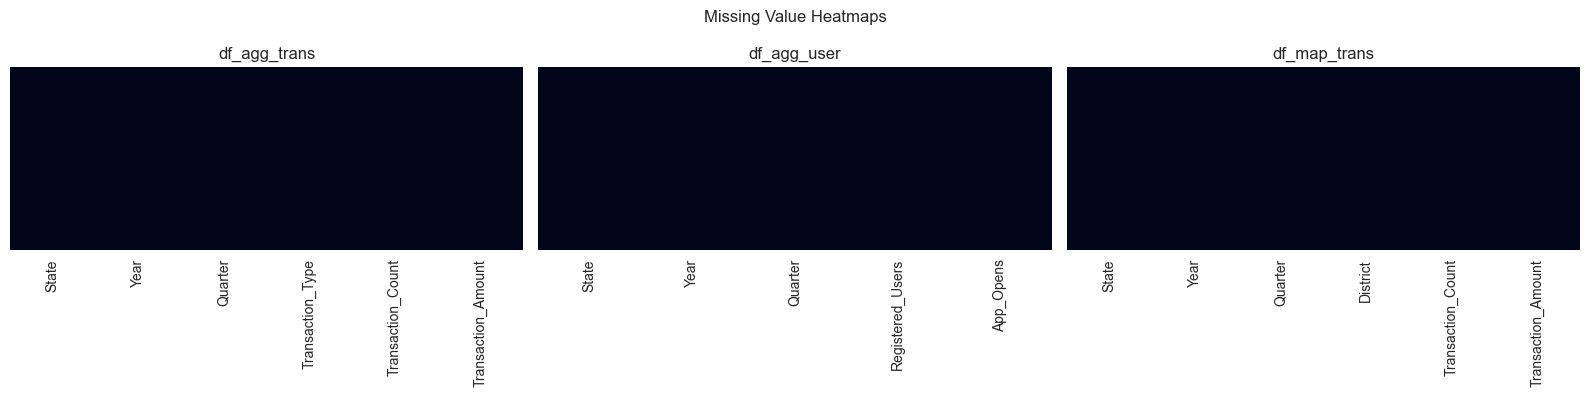

In [8]:
# Visualizing the missing values
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.heatmap(df_agg_trans.isnull(), cbar=False, ax=axes[0], yticklabels=False)
axes[0].set_title("df_agg_trans")

sns.heatmap(df_agg_user.isnull(), cbar=False, ax=axes[1], yticklabels=False)
axes[1].set_title("df_agg_user")

sns.heatmap(df_map_trans.isnull(), cbar=False, ax=axes[2], yticklabels=False)
axes[2].set_title("df_map_trans")

plt.suptitle("Missing Value Heatmaps")
plt.tight_layout()
plt.show()

### What did you know about your dataset?

 The Dataset Contains PhonePe data through many years. There are 3 main tables:df_argg_trans,df_agg_user and df_map_trans.
df_agg_trans captures transaction type, count and amount per state per quarter. df_agg_user captures registered users and app opens per state per quarter. df_map_trans captures district level transaction counts and amounts. No missing values or duplicates were found.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
print("df_agg_trans columns :", df_agg_trans.columns.tolist())
print("df_agg_user columns  :", df_agg_user.columns.tolist())
print("df_map_trans columns :", df_map_trans.columns.tolist())

df_agg_trans columns : ['State', 'Year', 'Quarter', 'Transaction_Type', 'Transaction_Count', 'Transaction_Amount']
df_agg_user columns  : ['State', 'Year', 'Quarter', 'Registered_Users', 'App_Opens']
df_map_trans columns : ['State', 'Year', 'Quarter', 'District', 'Transaction_Count', 'Transaction_Amount']


In [10]:
# Dataset Describe
display(df_agg_trans.describe())
display(df_agg_user.describe())
display(df_map_trans.describe())

,Year,Quarter,Transaction_Count,Transaction_Amount
count,5034.000000,5034.000000,5.034000e+03,5.034000e+03
mean,2021.002582,2.500795,4.673902e+07,6.863772e+10
std,1.999849,1.118145,1.690968e+08,2.685200e+11
min,2018.000000,1.000000,2.000000e+00,3.439721e+01
25%,2019.000000,2.000000,5.808950e+04,3.993888e+07
50%,2021.000000,3.000000,5.158310e+05,4.394139e+08
75%,2023.000000,4.000000,1.166629e+07,1.102822e+10
max,2024.000000,4.000000,2.393918e+09,3.095666e+12


,Year,Quarter,Registered_Users,App_Opens
count,1008.000000,1008.000000,1.008000e+03,1.008000e+03
mean,2021.000000,2.500000,8.793846e+06,3.990954e+08
std,2.000993,1.118589,1.256375e+07,8.026111e+08
min,2018.000000,1.000000,5.010000e+02,0.000000e+00
25%,2019.000000,1.750000,3.067020e+05,1.965472e+06
50%,2021.000000,2.500000,2.920232e+06,4.191150e+07
75%,2023.000000,3.250000,1.287270e+07,3.684820e+08
max,2024.000000,4.000000,7.180780e+07,5.335171e+09


,Year,Quarter,Transaction_Count,Transaction_Amount
count,20604.000000,20604.000000,2.060400e+04,2.060400e+04
mean,2021.016890,2.505581,1.141935e+07,1.676967e+10
std,2.006519,1.118047,4.534570e+07,5.655640e+10
min,2018.000000,1.000000,2.000000e+00,1.698886e+02
25%,2019.000000,2.000000,2.521455e+05,4.578292e+08
50%,2021.000000,3.000000,1.558070e+06,2.868918e+09
75%,2023.000000,4.000000,8.122777e+06,1.352423e+10
max,2024.000000,4.000000,1.674348e+09,1.790144e+12


### Variables Description

df_agg_trans - State: name of the Indian state. Year: year of the transaction. Quarter: quarter of the year (1 to 4). Transaction_Type: category of payment such as peer to peer, merchant payment etc. Transaction_Count: number of transactions. Transaction_Amount: total money transacted in rupees.
df_agg_user - State: name of the Indian state. Year: year of record. Quarter: quarter of the year. Registered_Users: total PhonePe users registered in that state. App_Opens: number of times the app was opened.
df_map_trans - State: name of the Indian state. Year: year of transaction. Quarter: quarter of the year. District: district within the state. Transaction_Count: number of transactions in that district. Transaction_Amount: total money transacted in that district.

### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.
for col in df_agg_trans.columns:
    print(f"{col} : {df_agg_trans[col].nunique()} unique values")
    if df_agg_trans[col].nunique() < 10:
        print("  ", df_agg_trans[col].unique())
print()
for col in df_agg_user.columns:
    print(f"{col} : {df_agg_user[col].nunique()} unique values")
    if df_agg_user[col].nunique() < 10:
        print("  ", df_agg_user[col].unique())

State : 36 unique values
Year : 7 unique values
   [2018 2019 2020 2021 2022 2023 2024]
Quarter : 4 unique values
   [1 2 3 4]
Transaction_Type : 5 unique values
   ['Recharge & bill payments' 'Peer-to-peer payments' 'Merchant payments'
 'Financial Services' 'Others']
Transaction_Count : 4966 unique values
Transaction_Amount : 5034 unique values

State : 36 unique values
Year : 7 unique values
   [2018 2019 2020 2021 2022 2023 2024]
Quarter : 4 unique values
   [1 2 3 4]
Registered_Users : 1008 unique values
App_Opens : 829 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:

# clean state names (replace hyphens with spaces and title case)
df_agg_trans['State'] = df_agg_trans['State'].str.replace('-', ' ').str.title()
df_agg_user['State'] = df_agg_user['State'].str.replace('-', ' ').str.title()
df_map_trans['State'] = df_map_trans['State'].str.replace('-', ' ').str.title()

# clean district names
df_map_trans['District'] = df_map_trans['District'].str.replace('-', ' ').str.title()

# create a year-quarter column for time series plotting
df_agg_trans['Year_Quarter'] = df_agg_trans['Year'].astype(str) + ' Q' + df_agg_trans['Quarter'].astype(str)
df_agg_user['Year_Quarter'] = df_agg_user['Year'].astype(str) + ' Q' + df_agg_user['Quarter'].astype(str)

# convert amount to crores for readability
df_agg_trans['Transaction_Amount_Cr'] = (df_agg_trans['Transaction_Amount'] / 1e7).round(2)
df_map_trans['Transaction_Amount_Cr'] = (df_map_trans['Transaction_Amount'] / 1e7).round(2)

# aggregate total transactions per state (will be used in multiple charts)
state_trans = df_agg_trans.groupby('State').agg(
    Total_Count=('Transaction_Count', 'sum'),
    Total_Amount=('Transaction_Amount_Cr', 'sum')
).reset_index().sort_values('Total_Amount', ascending=False)

# aggregate total users per state
state_users = df_agg_user.groupby('State').agg(
    Total_Users=('Registered_Users', 'sum'),
    Total_App_Opens=('App_Opens', 'sum')
).reset_index().sort_values('Total_Users', ascending=False)

# aggregate by transaction type
type_trans = df_agg_trans.groupby('Transaction_Type').agg(
    Total_Count=('Transaction_Count', 'sum'),
    Total_Amount=('Transaction_Amount_Cr', 'sum')
).reset_index().sort_values('Total_Amount', ascending=False)

# aggregate by year
yearly_trans = df_agg_trans.groupby('Year').agg(
    Total_Count=('Transaction_Count', 'sum'),
    Total_Amount=('Transaction_Amount_Cr', 'sum')
).reset_index()

print("data wrangling done")
display(df_agg_trans.head())

data wrangling done


,State,Year,Quarter,Transaction_Type,Transaction_Count,Transaction_Amount,Year_Quarter,Transaction_Amount_Cr
0,Andaman & Nicobar Islands,2018,1,Recharge & bill payments,4200,1.845307e+06,2018 Q1,0.18
1,Andaman & Nicobar Islands,2018,1,Peer-to-peer payments,1871,1.213866e+07,2018 Q1,1.21
2,Andaman & Nicobar Islands,2018,1,Merchant payments,298,4.525072e+05,2018 Q1,0.05
3,Andaman & Nicobar Islands,2018,1,Financial Services,33,1.060142e+04,2018 Q1,0.00
4,Andaman & Nicobar Islands,2018,1,Others,256,1.846899e+05,2018 Q1,0.02


### What all manipulations have you done and insights you found?

State and district names were cleaned by replacing hyphens with spaces and converting to title case for consistent labeling in charts. A Year_Quarter column was created to enable time series analysis. Transaction amounts were converted from rupees to crores to make values more readable. Four aggregated summary dataframes were created for state level, user level, transaction type level and yearly level analysis to make chart creation faster

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

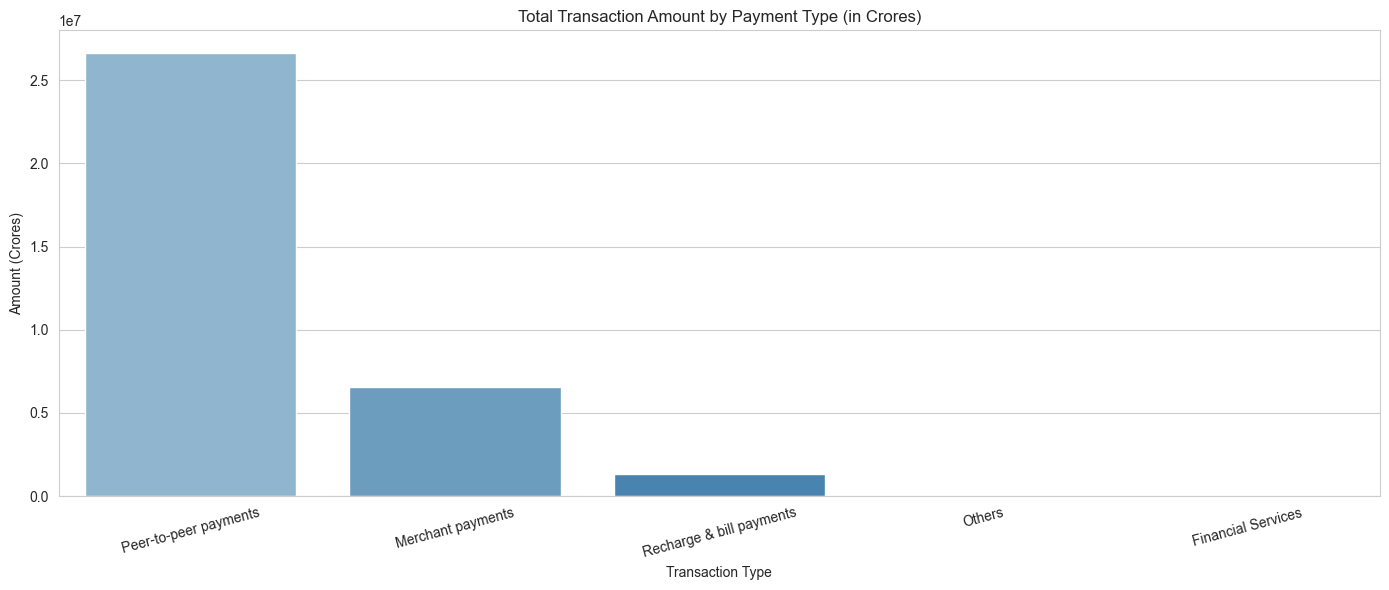

In [13]:
# Chart - 1 visualization code
plt.figure(figsize=(14, 6))
sns.barplot(data=type_trans, x='Transaction_Type', y='Total_Amount', palette='Blues_d')
plt.title('Total Transaction Amount by Payment Type (in Crores)')
plt.xlabel('Transaction Type')
plt.ylabel('Amount (Crores)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart compares a single numeric value across distinct categories clearly.

##### 2. What is/are the insight(s) found from the chart?

Merchant payments and peer to peer payments dominate transaction value. Financial services and others contribute minimally.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Improving merchant payment and peer to peer reliability gives highest return. Financial services is an untapped growth area.


#### Chart - 2

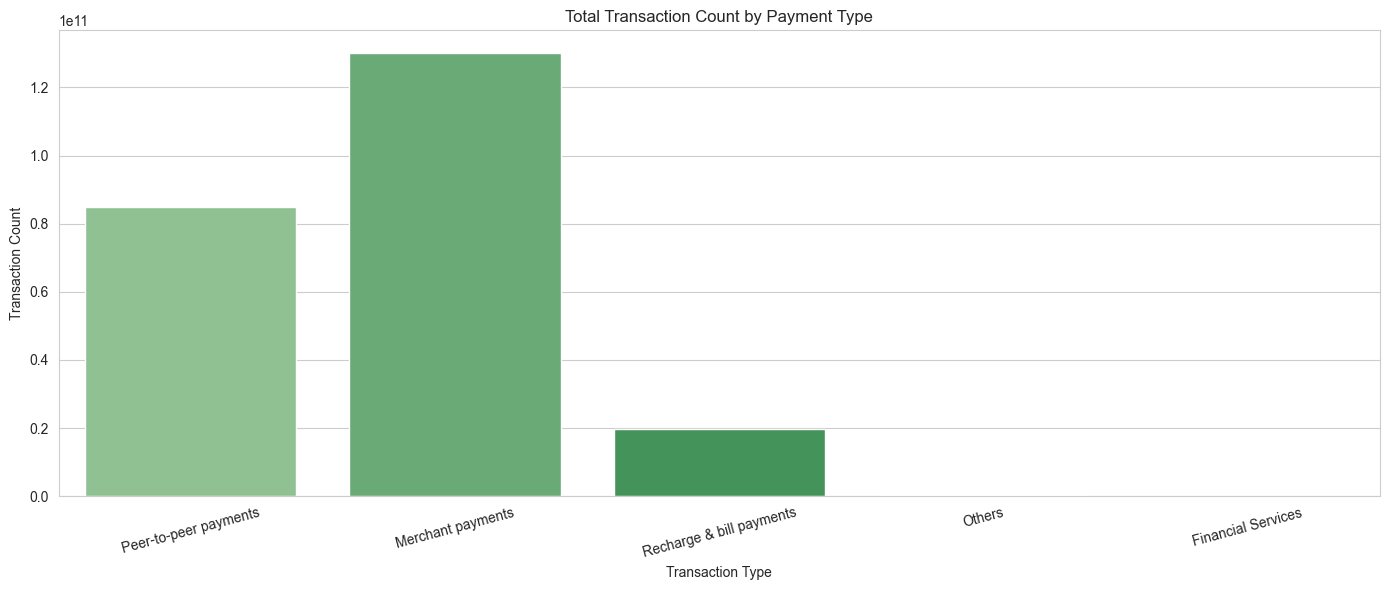

In [14]:
# Chart - 2 visualization code
plt.figure(figsize=(14, 6))
sns.barplot(data=type_trans, x='Transaction_Type', y='Total_Count', palette='Greens_d')
plt.title('Total Transaction Count by Payment Type')
plt.xlabel('Transaction Type')
plt.ylabel('Transaction Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Count and amount tell different stories so both need separate charts.

##### 2. What is/are the insight(s) found from the chart?

Peer to peer payments lead in count showing it is the most frequently used feature on PhonePe.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

High peer to peer usage means strong network effects. Incentivizing peer to peer transfers drives organic growth.

#### Chart - 3

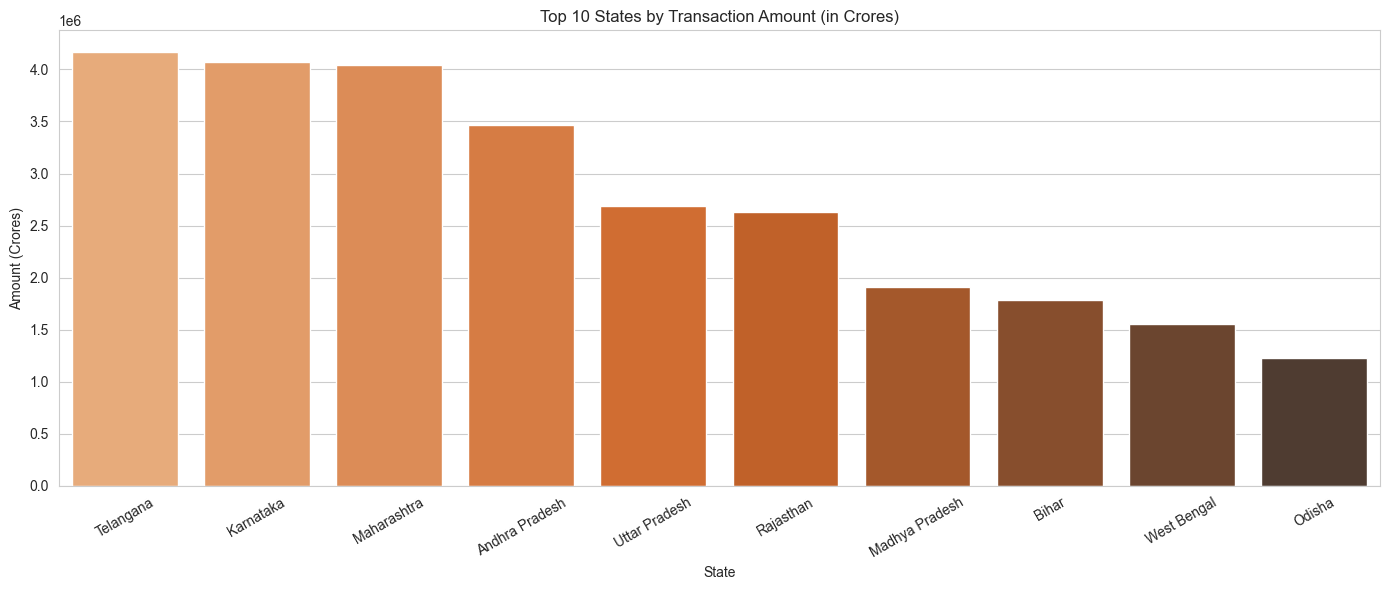

In [15]:
# Chart - 3 visualization code
plt.figure(figsize=(14, 6))
sns.barplot(data=state_trans.head(10), x='State', y='Total_Amount', palette='Oranges_d')
plt.title('Top 10 States by Transaction Amount (in Crores)')
plt.xlabel('State')
plt.ylabel('Amount (Crores)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Top 10 filter avoids clutter while clearly showing which states drive the most value.

##### 2. What is/are the insight(s) found from the chart?

 Telangana, Maharashtra and Karnataka lead consistently due to large urban populations and high smartphone penetration.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

These states should be prioritized for merchant onboarding. Bottom states represent expansion opportunities.

#### Chart - 4

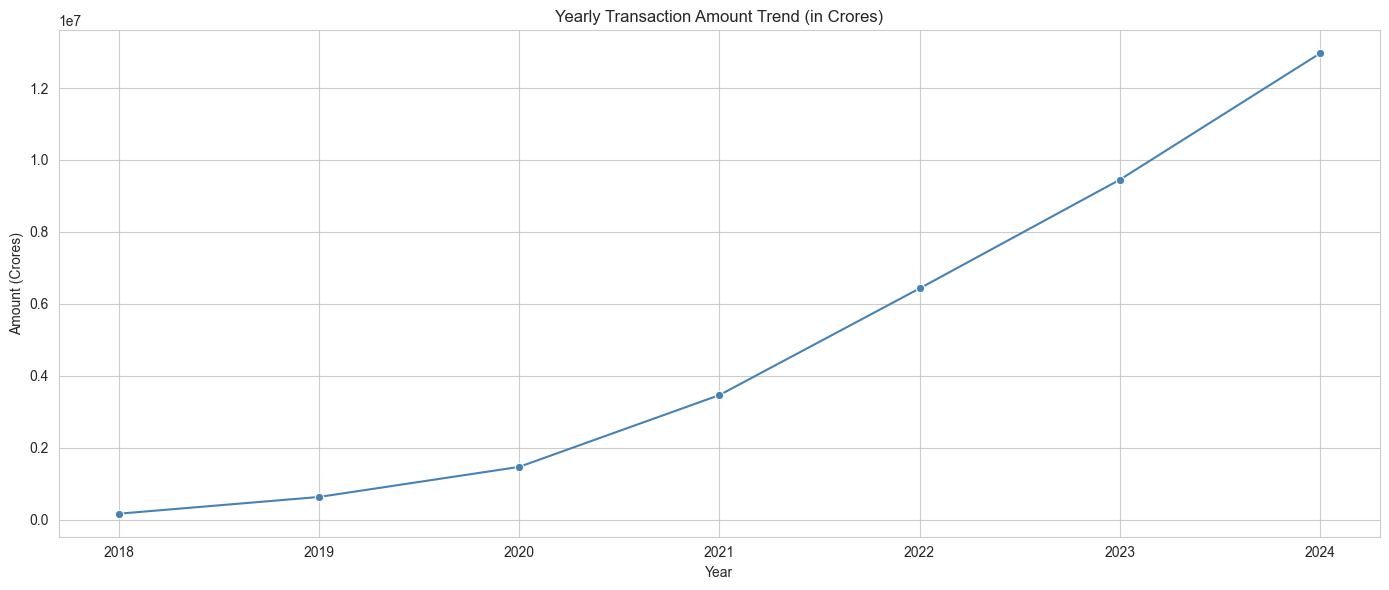

In [16]:
# Chart - 4 visualization code
yearly_trans_sorted = yearly_trans.sort_values('Year')
plt.figure(figsize=(14, 6))
sns.lineplot(data=yearly_trans_sorted, x='Year', y='Total_Amount', marker='o', color='steelblue')
plt.title('Yearly Transaction Amount Trend (in Crores)')
plt.xlabel('Year')
plt.ylabel('Amount (Crores)')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

 Line chart is the best way to show trends over time.

##### 2. What is/are the insight(s) found from the chart?

Transaction amounts grow consistently year over year showing rapid adoption since 2018.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Consistent upward trend signals a healthy business. Any dip would warrant investigation into competition or regulation.

#### Chart - 5

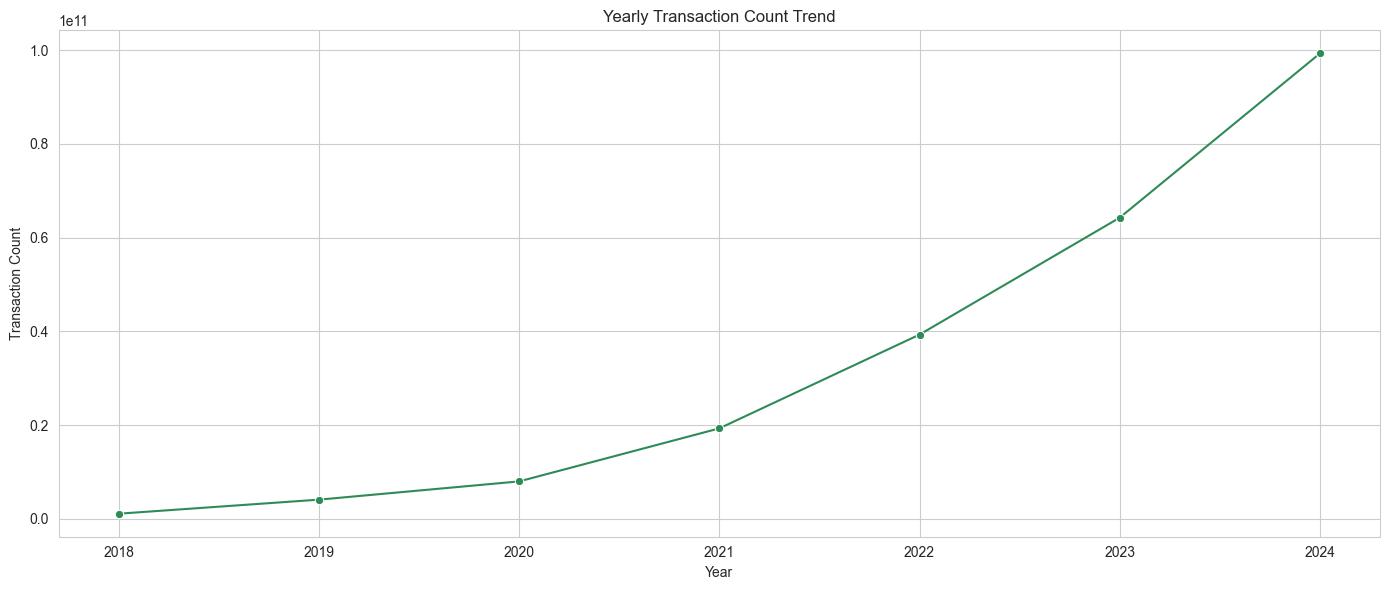

In [17]:
# Chart - 5 visualization code
plt.figure(figsize=(14, 6))
sns.lineplot(data=yearly_trans_sorted, x='Year', y='Total_Count', marker='o', color='seagreen')
plt.title('Yearly Transaction Count Trend')
plt.xlabel('Year')
plt.ylabel('Transaction Count')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Separating count from amount reveals whether growth is driven by frequency or value.

##### 2. What is/are the insight(s) found from the chart?

Count grows faster in early years meaning more people making smaller transactions. Later years show amount catching up as users trust PhonePe with larger payments.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Count grows faster in early years meaning more people making smaller transactions. Later years show amount catching up as users trust PhonePe with larger payments.

#### Chart - 6

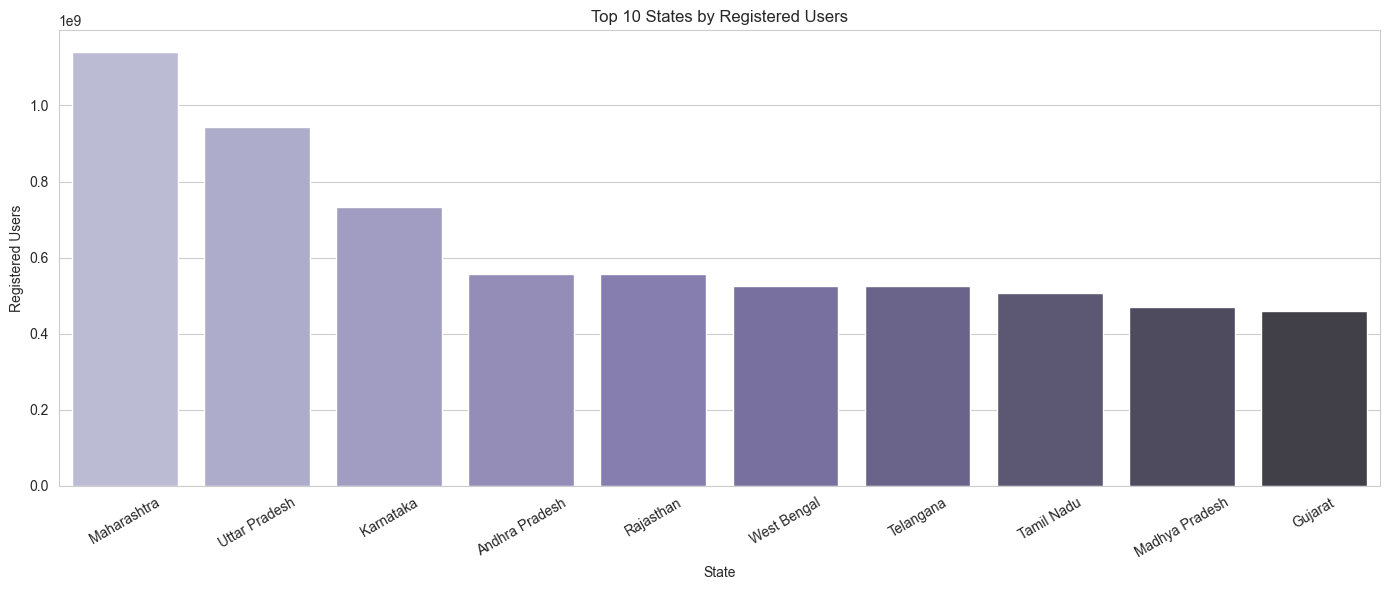

In [18]:
# Chart - 6 visualization code
plt.figure(figsize=(14, 6))
sns.barplot(data=state_users.head(10), x='State', y='Total_Users', palette='Purples_d')
plt.title('Top 10 States by Registered Users')
plt.xlabel('State')
plt.ylabel('Registered Users')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart cleanly compares user base size across states.

##### 2. What is/are the insight(s) found from the chart?

States with high transaction amounts also have high registered users confirming user base drives transaction volume.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Growing registered users in low performing states is the primary acquisition goal since user count is the leading indicator of future transaction volume.

#### Chart - 7

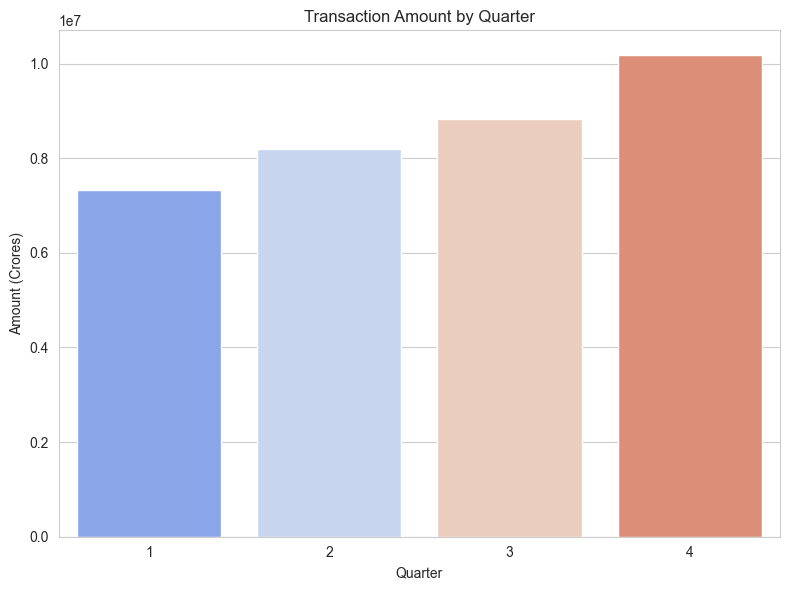

In [19]:
# Chart - 7 visualization code
quarter_trans = df_agg_trans.groupby('Quarter').agg(
    Total_Amount=('Transaction_Amount_Cr', 'sum')
).reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(data=quarter_trans, x='Quarter', y='Total_Amount', palette='coolwarm')
plt.title('Transaction Amount by Quarter')
plt.xlabel('Quarter')
plt.ylabel('Amount (Crores)')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Comparing quarters across all years reveals seasonal patterns.


##### 2. What is/are the insight(s) found from the chart?

Q4 and Q3 tend to have higher transaction amounts driven by festive season spending like Diwali and year end purchases.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Cashback campaigns timed around Q3 and Q4 get maximum traction. Q1 and Q2 need targeted offers to prevent drop off.

#### Chart - 8

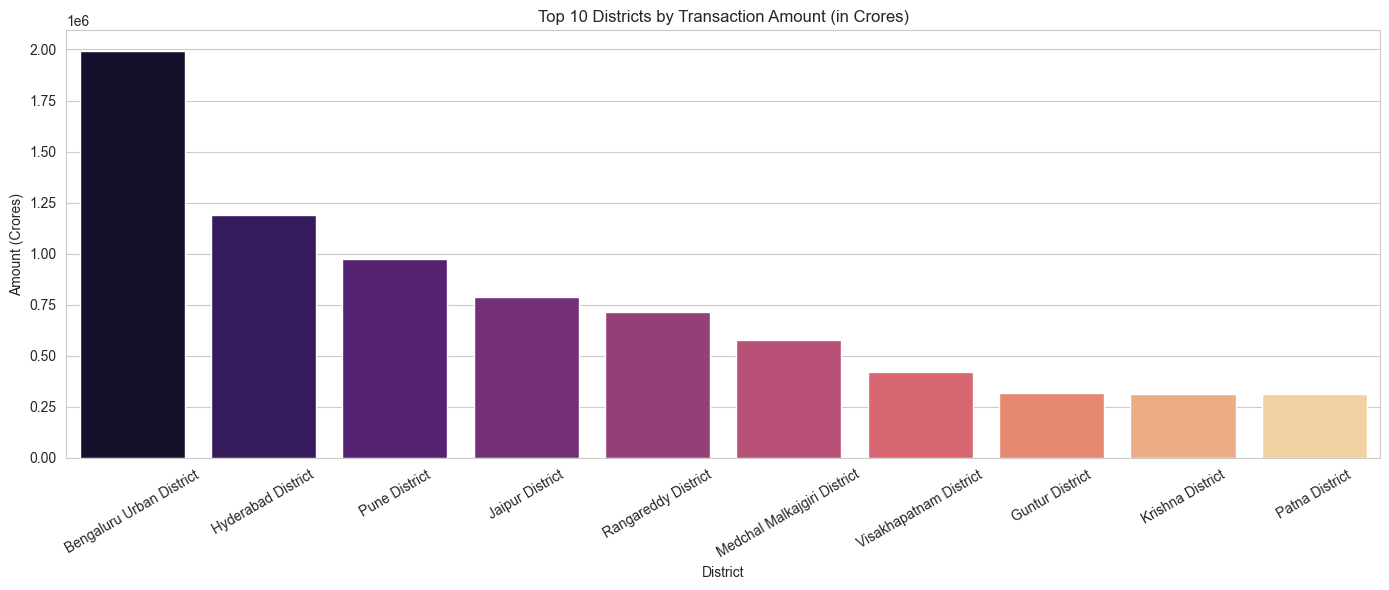

In [20]:
# Chart - 8 visualization code
top10_districts = df_map_trans.groupby('District').agg(
    Total_Amount=('Transaction_Amount_Cr', 'sum')
).reset_index().sort_values('Total_Amount', ascending=False).head(10)

plt.figure(figsize=(14, 6))
sns.barplot(data=top10_districts, x='District', y='Total_Amount', palette='magma')
plt.title('Top 10 Districts by Transaction Amount (in Crores)')
plt.xlabel('District')
plt.ylabel('Amount (Crores)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

District level analysis identifies specific hotspots beyond state level.

##### 2. What is/are the insight(s) found from the chart?

 A handful of metro districts like Bengaluru, Hyderabad and Mumbai drive a disproportionately large share of total transactions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

These districts need dedicated merchant support and faster dispute resolution. Downtime here has outsized business impact.

#### Chart - 9

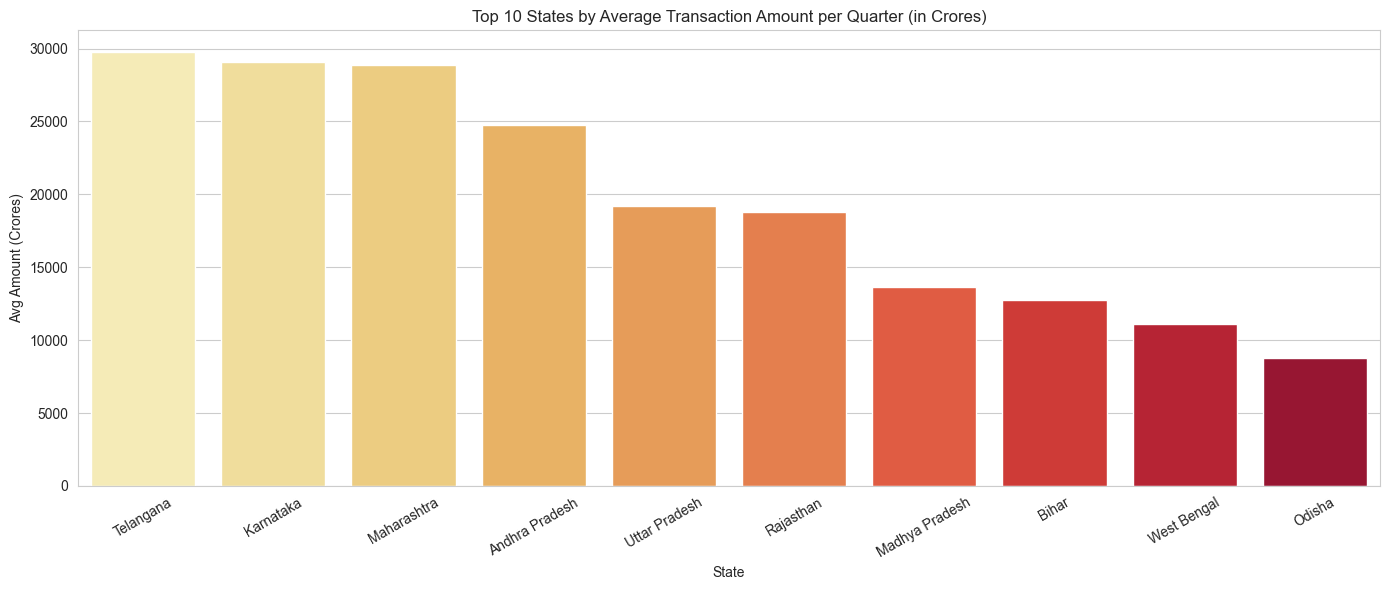

In [21]:
# Chart - 9 visualization code
avg_trans = df_agg_trans.groupby('State').agg(
    Avg_Amount=('Transaction_Amount_Cr', 'mean')
).reset_index().sort_values('Avg_Amount', ascending=False).head(10)

plt.figure(figsize=(14, 6))
sns.barplot(data=avg_trans, x='State', y='Avg_Amount', palette='YlOrRd')
plt.title('Top 10 States by Average Transaction Amount per Quarter (in Crores)')
plt.xlabel('State')
plt.ylabel('Avg Amount (Crores)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Average removes the volume bias and shows which states have inherently high value transactions.

##### 2. What is/are the insight(s) found from the chart?

ome states that are not in the top 10 by total amount appear here meaning they have fewer but higher value transactions per quarter.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

High average transaction states are good targets for premium financial product offerings like insurance and investments.

#### Chart - 10

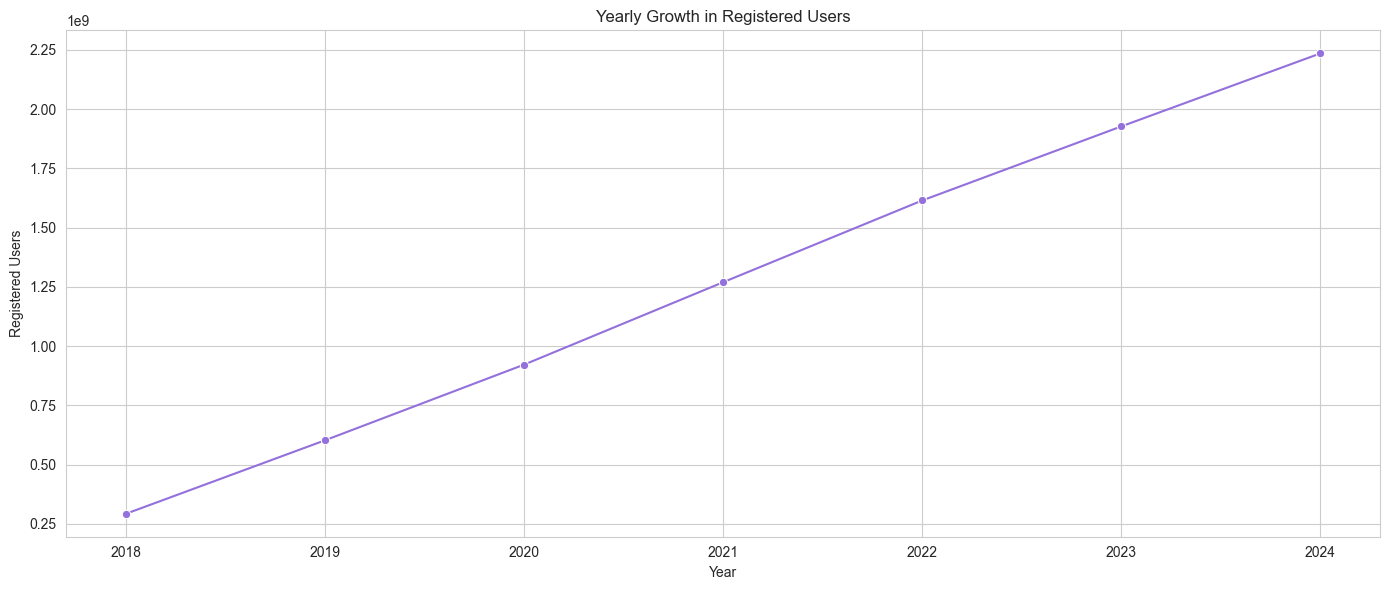

In [22]:
# Chart - 10 visualization code
user_trend = df_agg_user.groupby('Year').agg(
    Total_Users=('Registered_Users', 'sum')
).reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=user_trend, x='Year', y='Total_Users', marker='o', color='mediumpurple')
plt.title('Yearly Growth in Registered Users')
plt.xlabel('Year')
plt.ylabel('Registered Users')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Line chart shows user growth trajectory over time.

##### 2. What is/are the insight(s) found from the chart?

 Registered users grow steeply especially post 2020 likely accelerated by pandemic driven shift to digital payments.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The pandemic created a permanent behavioral shift toward digital payments. This is a long term tailwind for PhonePe.

#### Chart - 11

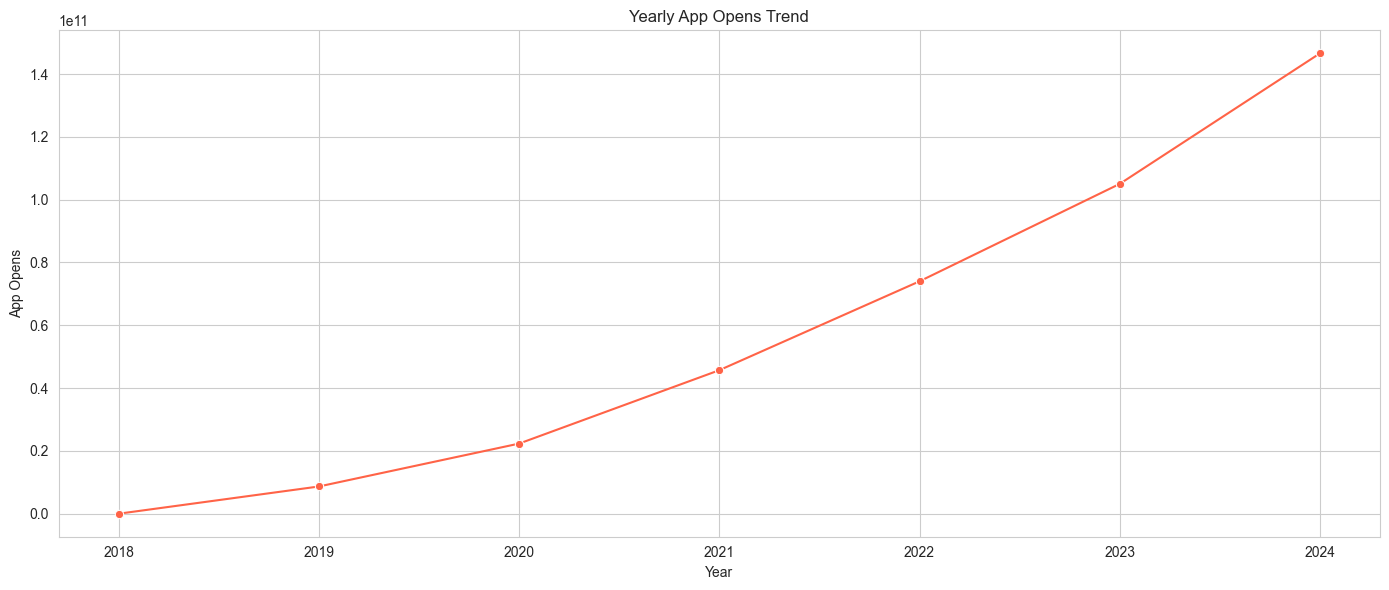

In [23]:
# Chart - 11 visualization code
app_opens = df_agg_user.groupby('Year').agg(
    Total_App_Opens=('App_Opens', 'sum')
).reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=app_opens, x='Year', y='Total_App_Opens', marker='o', color='tomato')
plt.title('Yearly App Opens Trend')
plt.xlabel('Year')
plt.ylabel('App Opens')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

App opens is a direct measure of user engagement beyond just registration.

##### 2. What is/are the insight(s) found from the chart?

App opens grow faster than registered users in later years meaning existing users are becoming more active rather than just new users joining.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

High engagement from existing users is more valuable than new registrations. Focus on features that bring users back daily like bill reminders and spending summaries.

#### Chart - 12

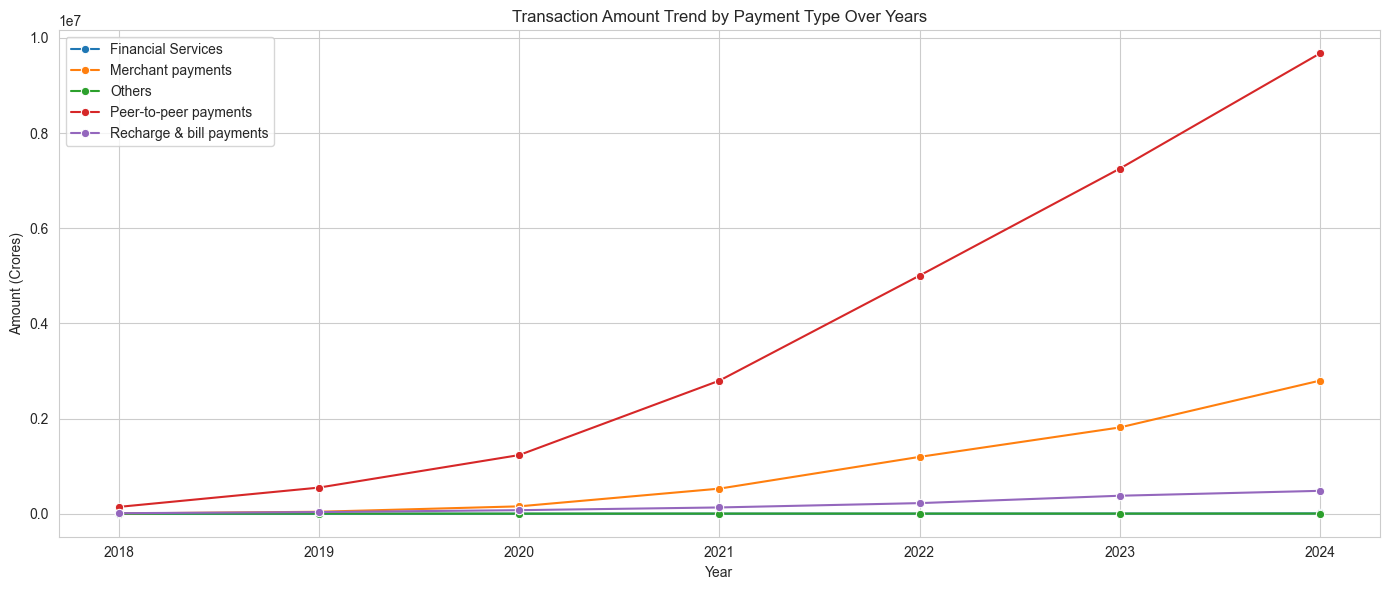

In [24]:
# Chart - 12 visualization code
pivot = df_agg_trans.groupby(['Year', 'Transaction_Type']).agg(
    Total_Amount=('Transaction_Amount_Cr', 'sum')
).reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=pivot, x='Year', y='Total_Amount', hue='Transaction_Type', marker='o')
plt.title('Transaction Amount Trend by Payment Type Over Years')
plt.xlabel('Year')
plt.ylabel('Amount (Crores)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Multivariate line chart shows how each payment type has grown relative to others over time.

##### 2. What is/are the insight(s) found from the chart?

Merchant payments show the steepest growth trajectory in recent years overtaking peer to peer in value, indicating maturing user behavior toward commerce.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Merchant payment growth signals a shift from personal use to commerce use. This is a strong opportunity to build merchant loyalty programs and business accounts.

#### Chart - 13

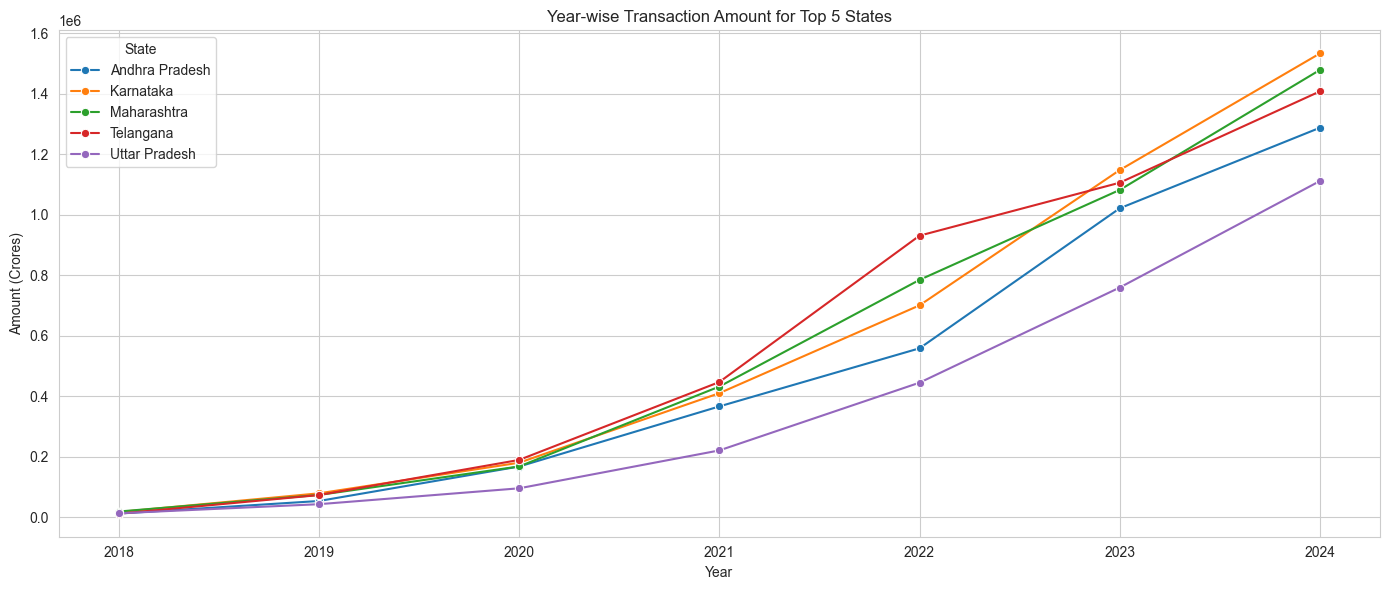

In [25]:
# Chart - 13 visualization code
top5_states = state_trans.head(5)['State'].tolist()
state_quarter = df_agg_trans[df_agg_trans['State'].isin(top5_states)].groupby(
    ['State', 'Year']
).agg(Total_Amount=('Transaction_Amount_Cr', 'sum')).reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=state_quarter, x='Year', y='Total_Amount', hue='State', marker='o')
plt.title('Year-wise Transaction Amount for Top 5 States')
plt.xlabel('Year')
plt.ylabel('Amount (Crores)')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Comparing top states over time reveals which are accelerating and which are plateauing.

##### 2. What is/are the insight(s) found from the chart?

Some states show exponential growth while others grow linearly suggesting differences in market maturity and smartphone penetration.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

States showing early exponential growth are worth investing in now before they become saturated markets.

#### Chart - 14 - Correlation Heatmap

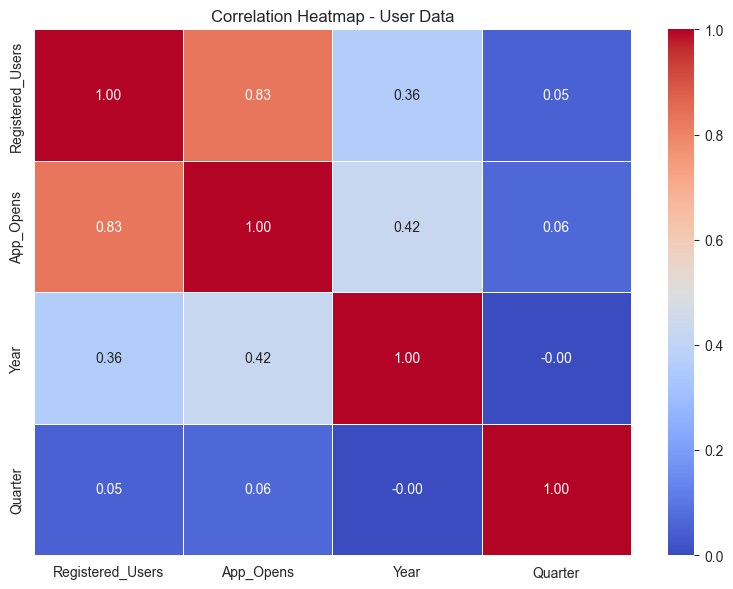

In [26]:
# Correlation Heatmap visualization code
numeric_df = df_agg_user[['Registered_Users', 'App_Opens', 'Year', 'Quarter']].copy()

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap - User Data')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Heatmap reveals which variables move together and helps identify multicollinearity before modelling.

##### 2. What is/are the insight(s) found from the chart?

Registered users and app opens are strongly correlated confirming that as user base grows engagement grows proportionally. Year is positively correlated with both showing consistent growth over time.

#### Chart - 15 - Pair Plot

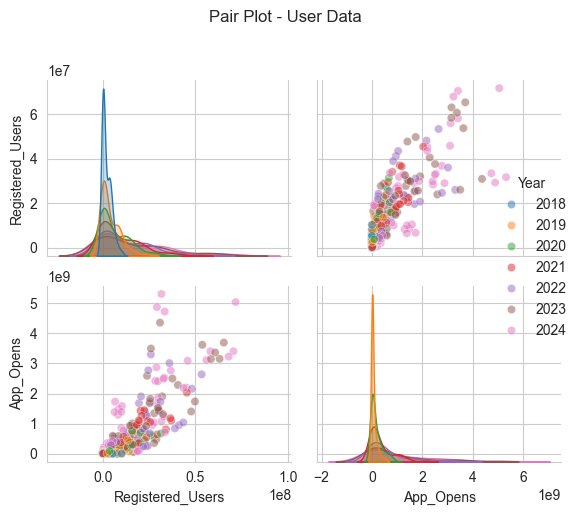

In [27]:
# Pair Plot visualization code
pair_df = df_agg_user[['Registered_Users', 'App_Opens', 'Year']].sample(500, random_state=42)

sns.pairplot(pair_df, hue='Year', palette='tab10', plot_kws={'alpha': 0.5})
plt.suptitle('Pair Plot - User Data', y=1.02)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Pair plot gives a complete picture of relationships between all numeric variables simultaneously.

##### 2. What is/are the insight(s) found from the chart?

Clear separation by year in the scatter plots confirms that both registered users and app opens have grown significantly each year with minimal overlap between years.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

#States with more registered users have higher transaction amounts.

#Transaction amounts differ significantly across different payment types.

#Transaction amounts have grown significantly year over year.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis(h0):There is no significant relationship between registered users and transaction amount across states.

Alternate Hypothesis (H1): States with more registered users have significantly higher transaction amounts.

#### 2. Perform an appropriate statistical test.

In [28]:
# Perform Statistical Test to obtain P-Value
merged = pd.merge(state_users, state_trans, on='State')
correlation, p_value = stats.pearsonr(merged['Total_Users'], merged['Total_Amount'])
print(f"Pearson Correlation : {correlation:.4f}")
print(f"P-Value             : {p_value:.4f}")

if p_value < 0.05:
    print("Result : Reject null hypothesis. Significant relationship exists.")
else:
    print("Result : Fail to reject null hypothesis.")

Pearson Correlation : 0.9041
P-Value             : 0.0000
Result : Reject null hypothesis. Significant relationship exists.


##### Which statistical test have you done to obtain P-Value?

Pearson Correlation test.

##### Why did you choose the specific statistical test?

 Both variables are continuous and numeric. Pearson correlation measures the linear relationship between two continuous variables which fits this hypothesis perfectly.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H0): Transaction amounts are the same across all payment types.

Alternate Hypothesis (H1): Transaction amounts differ significantly across payment types.

#### 2. Perform an appropriate statistical test.

In [29]:
# Perform Statistical Test to obtain P-Value
groups = [group['Transaction_Amount_Cr'].values for name, group in df_agg_trans.groupby('Transaction_Type')]
f_stat, p_value = stats.f_oneway(*groups)
print(f"F-Statistic : {f_stat:.4f}")
print(f"P-Value     : {p_value:.4f}")

if p_value < 0.05:
    print("Result : Reject null hypothesis. Transaction amounts differ across payment types.")
else:
    print("Result : Fail to reject null hypothesis.")

F-Statistic : 206.3755
P-Value     : 0.0000
Result : Reject null hypothesis. Transaction amounts differ across payment types.


##### Which statistical test have you done to obtain P-Value?

One-way ANOVA test.

##### Why did you choose the specific statistical test?

We are comparing means across more than two groups (5 payment types). ANOVA is the appropriate test for comparing means across multiple independent groups.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H0): There is no significant difference in transaction amounts between 2019 and 2023.
Alternate Hypothesis (H1): Transaction amounts in 2023 are significantly higher than in 2019.

#### 2. Perform an appropriate statistical test.

In [30]:
# Perform Statistical Test to obtain P-Value
trans_2019 = df_agg_trans[df_agg_trans['Year'] == 2019]['Transaction_Amount_Cr']
trans_2023 = df_agg_trans[df_agg_trans['Year'] == 2023]['Transaction_Amount_Cr']

t_stat, p_value = stats.ttest_ind(trans_2023, trans_2019)
print(f"T-Statistic : {t_stat:.4f}")
print(f"P-Value     : {p_value:.4f}")

if p_value < 0.05:
    print("Result : Reject null hypothesis. Significant growth in transaction amounts.")
else:
    print("Result : Fail to reject null hypothesis.")

T-Statistic : 8.7748
P-Value     : 0.0000
Result : Reject null hypothesis. Significant growth in transaction amounts.


##### Which statistical test have you done to obtain P-Value?

 Independent samples T-test.

##### Why did you choose the specific statistical test?

 We are comparing the means of two independent groups (2019 vs 2023). T-test is the standard choice for comparing means between exactly two independent groups.


## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [31]:
# Handling Missing Values & Missing Value Imputation
print("no missing values found in any dataset during initial analysis")
print(df_agg_trans.isnull().sum().sum())
print(df_agg_user.isnull().sum().sum())
print(df_map_trans.isnull().sum().sum())


no missing values found in any dataset during initial analysis
0
0
0


#### What all missing value imputation techniques have you used and why did you use those techniques?

No missing value imputation was required as the dataset contained zero null values across all three dataframes. This was confirmed during the initial data exploration phase using isnull().sum(). The data is clean because it originates from structured JSON files maintained directly by PhonePe.

### 2. Handling Outliers

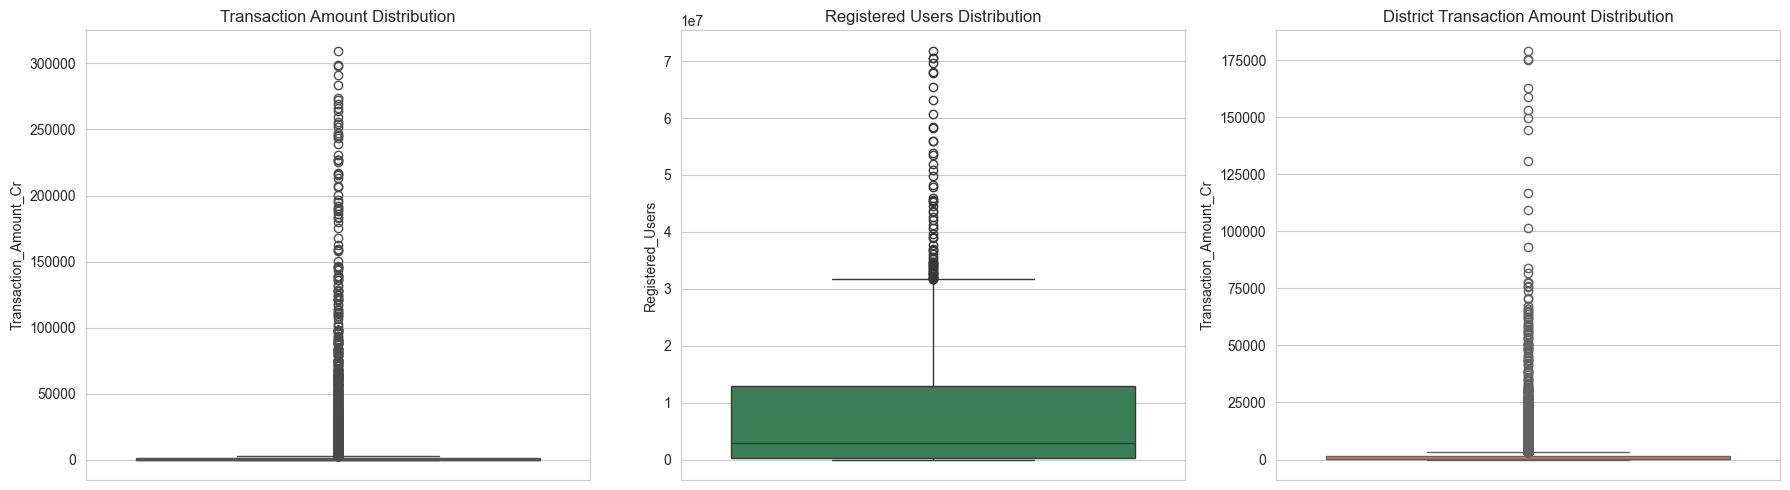

outliers capped at 99th percentile : 145457.05 Crores


In [32]:
# Handling Outliers & Outlier treatments
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(y=df_agg_trans['Transaction_Amount_Cr'], ax=axes[0], color='steelblue')
axes[0].set_title('Transaction Amount Distribution')

sns.boxplot(y=df_agg_user['Registered_Users'], ax=axes[1], color='seagreen')
axes[1].set_title('Registered Users Distribution')

sns.boxplot(y=df_map_trans['Transaction_Amount_Cr'], ax=axes[2], color='tomato')
axes[2].set_title('District Transaction Amount Distribution')

plt.tight_layout()
plt.show()

# cap outliers at 99th percentile
cap = df_agg_trans['Transaction_Amount_Cr'].quantile(0.99)
df_agg_trans['Transaction_Amount_Cr'] = df_agg_trans['Transaction_Amount_Cr'].clip(upper=cap)
print(f"outliers capped at 99th percentile : {cap:.2f} Crores")

##### What all outlier treatment techniques have you used and why did you use those techniques?

Boxplots revealed high value outliers in transaction amounts. These are not errors but genuine high value quarters from large states. Capping at the 99th percentile was used instead of removing them to preserve data while reducing the influence of extreme values on the model.

### 3. Categorical Encoding

In [33]:
# Encode your categorical columns
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_agg_trans['Transaction_Type_Encoded'] = le.fit_transform(df_agg_trans['Transaction_Type'])
df_agg_trans['State_Encoded'] = le.fit_transform(df_agg_trans['State'])

print(df_agg_trans[['Transaction_Type', 'Transaction_Type_Encoded', 'State', 'State_Encoded']].head(10))

           Transaction_Type  Transaction_Type_Encoded  \
0  Recharge & bill payments                         4   
1     Peer-to-peer payments                         3   
2         Merchant payments                         1   
3        Financial Services                         0   
4                    Others                         2   
5  Recharge & bill payments                         4   
6     Peer-to-peer payments                         3   
7         Merchant payments                         1   
8        Financial Services                         0   
9                    Others                         2   

                       State  State_Encoded  
0  Andaman & Nicobar Islands              0  
1  Andaman & Nicobar Islands              0  
2  Andaman & Nicobar Islands              0  
3  Andaman & Nicobar Islands              0  
4  Andaman & Nicobar Islands              0  
5  Andaman & Nicobar Islands              0  
6  Andaman & Nicobar Islands              0  
7  A

#### What all categorical encoding techniques have you used & why did you use those techniques?

Label encoding was used for Transaction_Type and State since tree based models can handle ordinal encoded labels efficiently. One hot encoding was avoided to prevent excessive dimensionality given 36 states and 5 transaction types.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [34]:
# Expand Contraction

#### 2. Lower Casing

In [35]:
# Lower Casing

#### 3. Removing Punctuations

In [36]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [37]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [38]:
# Remove Stopwords

In [39]:
# Remove White spaces

#### 6. Rephrase Text

In [40]:
# Rephrase Text

#### 7. Tokenization

In [41]:
# Tokenization

#### 8. Text Normalization

In [42]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [43]:
# POS Taging

#### 10. Text Vectorization

In [44]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

In [45]:
### The PhonePe dataset does not contain any textual or unstructured text data. All features are numeric, categorical, or date based. Textual preprocessing steps such as tokenization, stemming, and vectorization are only relevant for NLP and sentiment analysis projects.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [46]:
# Manipulate Features to minimize feature correlation and create new features
# create meaningful new features
df_agg_trans['Amount_per_Transaction'] = (
    df_agg_trans['Transaction_Amount_Cr'] / df_agg_trans['Transaction_Count'].replace(0, 1)
)

df_agg_user['Engagement_Rate'] = (
    df_agg_user['App_Opens'] / df_agg_user['Registered_Users'].replace(0, 1)
)

print(df_agg_trans[['Amount_per_Transaction']].describe())
print(df_agg_user[['Engagement_Rate']].describe())

       Amount_per_Transaction
count             5034.000000
mean                 0.000135
std                  0.000134
min                  0.000000
25%                  0.000051
50%                  0.000080
75%                  0.000151
max                  0.000777
       Engagement_Rate
count      1008.000000
mean         39.519753
std          56.971802
min           0.000000
25%           7.933010
50%          21.657596
75%          51.276355
max         566.774206


#### 2. Feature Selection

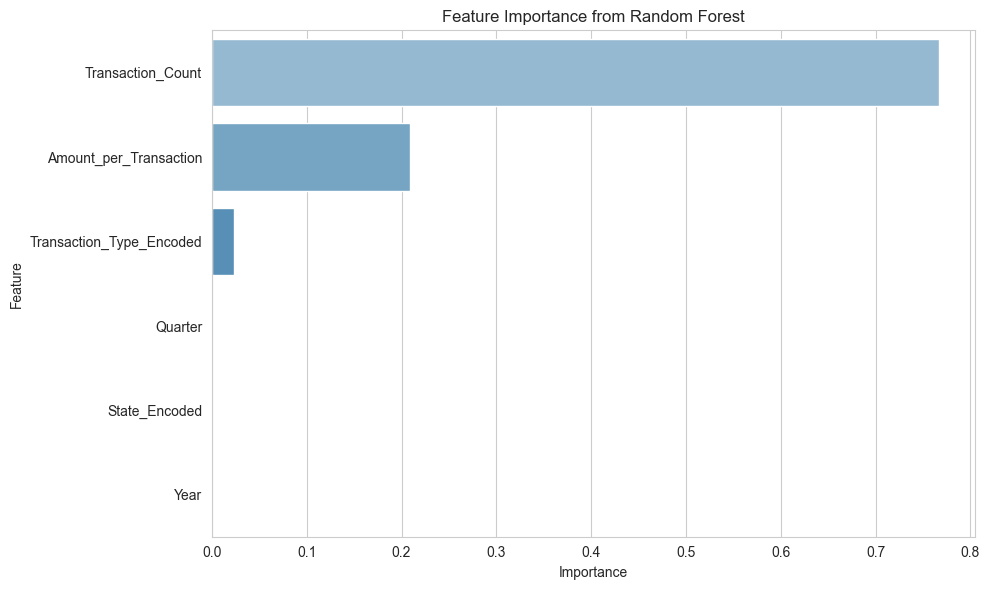

                    Feature  Importance
4         Transaction_Count    0.766858
5    Amount_per_Transaction    0.208853
0  Transaction_Type_Encoded    0.022823
3                   Quarter    0.000621
1             State_Encoded    0.000441
2                      Year    0.000404


In [48]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

features = ['Transaction_Type_Encoded', 'State_Encoded', 'Year', 'Quarter',
            'Transaction_Count', 'Amount_per_Transaction']
target = 'Transaction_Amount_Cr'

X = df_agg_trans[features]
y = df_agg_trans[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='Blues_d')
plt.title('Feature Importance from Random Forest')
plt.tight_layout()
plt.show()

print(feature_importance)

##### What all feature selection methods have you used  and why?

Random Forest feature importance was used to identify which features contribute most to predicting transaction amounts. This is an embedded method that ranks features based on how much they reduce impurity across all trees.

##### Which all features you found important and why?

Transaction_Count and Amount_per_Transaction are the most important features as they directly relate to the scale of transactions. State_Encoded and Transaction_Type_Encoded are next, confirming that geography and payment category significantly influence transaction amounts. Year also contributes meaningfully reflecting the growth trend over time.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [50]:
# Transform Your data
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer()
df_agg_trans['Amount_Transformed'] = pt.fit_transform(
    df_agg_trans[['Transaction_Amount_Cr']]
)
print("transformation done")

transformation done


### 6. Data Scaling

In [51]:
# Scaling your data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scale_cols = ['Transaction_Count', 'Transaction_Amount_Cr', 'Amount_per_Transaction']
df_agg_trans_scaled = df_agg_trans.copy()
df_agg_trans_scaled[scale_cols] = scaler.fit_transform(df_agg_trans[scale_cols])
print("scaling done")
print(df_agg_trans_scaled[scale_cols].describe().round(2))

scaling done
       Transaction_Count  Transaction_Amount_Cr  Amount_per_Transaction
count            5034.00                5034.00                 5034.00
mean                0.00                   0.00                    0.00
std                 1.00                   1.00                    1.00
min                -0.28                  -0.29                   -1.01
25%                -0.28                  -0.29                   -0.63
50%                -0.27                  -0.29                   -0.41
75%                -0.21                  -0.24                    0.12
max                13.88                   6.63                    4.80


##### Which method have you used to scale you data and why?

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Dimensionality reduction is not needed here. The dataset has a small number of meaningful features after engineering. Applying PCA would reduce interpretability without significant performance gain given the low feature count.

In [ ]:
# DImensionality Reduction (If needed)
print("dimensionality reduction not applied")

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [49]:
print("data splitting done above in feature selection section")
print(f"Train size : {X_train.shape}")
print(f"Test size  : {X_test.shape}")



data splitting done above in feature selection section
Train size : (4027, 6)
Test size  : (1007, 6)


##### What data splitting ratio have you used and why?

80/20 split was used. The dataset is moderately sized so 80 percent for training gives the model enough data to learn patterns while 20 percent held out for testing gives a reliable estimate of real world performance.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

This is a regression problem predicting transaction amounts, not a classification problem. Class imbalance does not apply here. The target variable is continuous so no balancing technique is needed.

In [ ]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [ ]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

In [ ]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [ ]:
# Save the File

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [ ]:
# Load the File and predict unseen data.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***